# Cross-Sectional Regression
Build regression dataset, fit OLS, run diagnostics.

Dropping constant variables with 0 variance: ['IsCEO', 'IsCFO', 'Is10pctOwner']



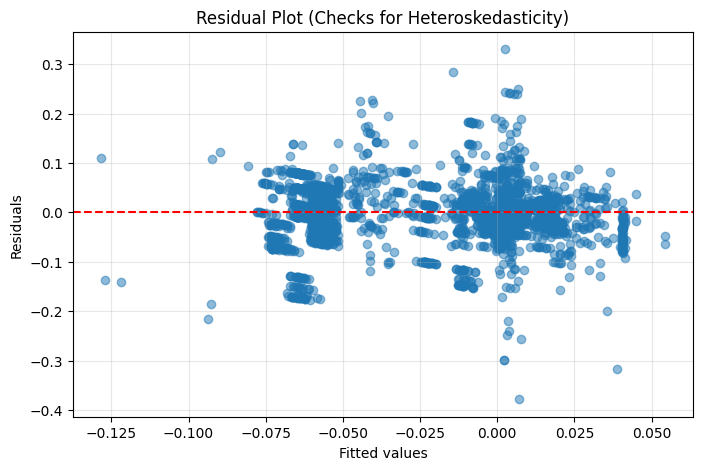

--------------------------------------------------
DIAGNOSTICS
--------------------------------------------------
Breusch-Pagan p-value: 0.0000
-> Heteroskedasticity detected (p < 0.05).

Variance Inflation Factors (VIF):
               feature          VIF
0                const  1194.189879
1  LogTransactionValue     1.115646
2          LogFirmSize     1.141651
3             BuyDummy   424.662474
4          Interaction   423.837776
5           IsDirector     1.211122
6       IsOtherOfficer     1.098375

FINAL REGRESSION MODEL (WITH ROBUST STANDARD ERRORS)
                            OLS Regression Results                            
Dep. Variable:                    CAR   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     224.3
Date:                Wed, 12 Aug 2026   Prob (F-statistic):          1.56e-237
Time:                        18:32:22   L

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load Data
events_df = pd.read_csv('../data/processed/events_with_car.csv')
mc_df = pd.read_csv('../data/processed/market_caps.csv')
events_df = events_df.merge(mc_df, left_on='ISSUERTRADINGSYMBOL', right_on='Ticker', how='left')

# Prepare Variables
events_df['LogTransactionValue'] = np.log(events_df['TransactionValue'])
events_df['LogFirmSize'] = np.log(events_df['MarketCap'].replace(0, np.nan))

events_df['BuyDummy'] = (events_df['TRANS_CODE'] == 'P').astype(int)
events_df['Interaction'] = events_df['BuyDummy'] * events_df['LogFirmSize']

# Dummy for Insider Role
rel = events_df['RPTOWNER_RELATIONSHIP'].fillna('')
events_df['IsCEO'] = rel.str.contains('CEO', case=False).astype(int)
events_df['IsCFO'] = rel.str.contains('CFO', case=False).astype(int)
events_df['IsDirector'] = rel.str.contains('Director', case=False).astype(int)
events_df['Is10pctOwner'] = rel.str.contains('10%', case=False).astype(int)
events_df['IsOtherOfficer'] = (rel.str.contains('Officer', case=False) & ~rel.str.contains('CEO|CFO', case=False)).astype(int)

# Regression Dataset
cols = ['CAR', 'LogTransactionValue', 'LogFirmSize', 'BuyDummy', 'Interaction', 
        'IsCEO', 'IsCFO', 'IsDirector', 'Is10pctOwner', 'IsOtherOfficer']
reg_data = events_df[cols].dropna()

# Automatically drop any variables that have 0 variance (i.e. are constant) to prevent singular matrix errors
constant_cols = [col for col in reg_data.columns if reg_data[col].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant variables with 0 variance: {constant_cols}\n")
    reg_data = reg_data.drop(columns=constant_cols)

X_cols = [c for c in reg_data.columns if c != 'CAR']
X = reg_data[X_cols]
X = sm.add_constant(X)
y = reg_data['CAR']

# Fit OLS with standard errors initially to check for heteroskedasticity
initial_model = sm.OLS(y, X).fit()

# Residual Plot
plt.figure(figsize=(8,5))
plt.scatter(initial_model.fittedvalues, initial_model.resid, alpha=0.5)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Checks for Heteroskedasticity)')
plt.axhline(0, color='red', linestyle='--')
plt.grid(True, alpha=0.3)
plt.savefig('../report/residual_plot.png')
plt.show()

# Diagnostics
print("-" * 50)
print("DIAGNOSTICS")
print("-" * 50)
# Heteroskedasticity (Breusch-Pagan)
try:
    bp_test = het_breuschpagan(initial_model.resid, initial_model.model.exog)
    print(f"Breusch-Pagan p-value: {bp_test[1]:.4f}")
    if bp_test[1] < 0.05:
        print("-> Heteroskedasticity detected (p < 0.05).")
    else:
        print("-> No heteroskedasticity detected.")
except Exception as e:
    print(f"Could not run Breusch-Pagan test: {e}")

# Multicollinearity (VIF)
try:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    # Add a small epsilon to variance calculation if VIF fails, but dropping constants should fix it
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print("\nVariance Inflation Factors (VIF):")
    print(vif_data)
except Exception as e:
    print(f"Could not calculate VIF: {e}")

print("\n" + "=" * 50)
print("FINAL REGRESSION MODEL (WITH ROBUST STANDARD ERRORS)")
print("=" * 50)
# Due to the funnel/banding pattern in the residual plot indicating heteroskedasticity, 
# we use White's HC3 robust standard errors to calculate reliable t-stats and p-values.
robust_model = sm.OLS(y, X).fit(cov_type='HC3')
print(robust_model.summary())
